<a href="https://colab.research.google.com/github/GifariMadia/data-science-portfolio/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_clean_data(filepath: str) -> pd.DataFrame:
    """
    Memuat dataset Telco Churn dan membersihkan anomali tipe data.
    """
    df = pd.read_csv(filepath)

    # KEPUTUSAN: Kolom TotalCharges terbaca sebagai string karena ada spasi pada
    # pelanggan baru (tenure = 0). Kita paksa konversi ke numerik (errors='coerce').
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

    # KEPUTUSAN: Mengisi nilai NaN pada TotalCharges dengan 0.
    # Logika bisnis: Pelanggan dengan tenure 0 belum ditagih, sehingga total bayar adalah 0.
    df['TotalCharges'] = df['TotalCharges'].fillna(0)

    # KEPUTUSAN: Ubah target 'Churn' menjadi binary (1/0) sejak awal.
    # Ini wajib dilakukan agar metrik korelasi dan probabilitas model mudah dihitung.
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

    return df

def perform_directed_eda(df: pd.DataFrame):
    """
    Melakukan visualisasi spesifik untuk menjawab 3 pertanyaan bisnis utama.
    """
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Analisis Tenure vs Churn
    sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0])
    axes[0].set_title('Distribusi Tenure pada Churn')
    axes[0].set_xticklabels(['Bertahan (0)', 'Churn (1)'])

    # 2. Analisis Contract vs Churn
    # KEPUTUSAN: Menghitung rata-rata Churn (karena sudah 1/0) memberikan persentase churn rate.
    contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
    sns.barplot(x='Contract', y='Churn', data=contract_churn, ax=axes[1])
    axes[1].set_title('Rasio Churn per Tipe Kontrak')
    axes[1].set_ylabel('Churn Rate')

    # 3. Analisis MonthlyCharges vs Churn
    sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', common_norm=False, ax=axes[2])
    axes[2].set_title('Distribusi Tagihan Bulanan')

    plt.tight_layout()
    plt.show()

# Eksekusi (Asumsi file ada di direktori yang sama)
# df = load_and_clean_data('WA_Fn-UseC_-Telco-Customer-Churn.csv')
# perform_directed_eda(df)

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_score, recall_score
from imblearn.over_sampling import SMOTE

def preprocess_and_split(df: pd.DataFrame):
    """
    Melakukan feature engineering (OHE) dan membagi data (Train/Test)
    untuk menghindari data leakage sebelum handling imbalance.
    """
    # Drop kolom ID yang tidak memiliki nilai prediktif
    if 'customerID' in df.columns:
        df = df.drop(columns=['customerID'])

    X = df.drop(columns=['Churn'])
    y = df['Churn']

    # KEPUTUSAN: drop_first=True untuk menghindari jebakan multikolinearitas (dummy trap),
    # sangat krusial untuk Logistic Regression.
    X_encoded = pd.get_dummies(X, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=0.2, random_state=42, stratify=y
    )

    # Scale numerik
    scaler = StandardScaler()
    num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

    return X_train, X_test, y_train, y_test

def evaluate_models(X_train, X_test, y_train, y_test):
    """
    Melatih dan membandingkan baseline vs model kompleks
    menggunakan strategi class_weight dan SMOTE.
    """
    results = []

    # 1. Baseline: Logistic Regression (dengan class_weight)
    lr_cw = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
    lr_cw.fit(X_train, y_train)
    y_pred_lr = lr_cw.predict(X_test)
    results.append({
        'Model': 'LogReg (Class Weight)',
        'Precision': precision_score(y_test, y_pred_lr),
        'Recall': recall_score(y_test, y_pred_lr)
    })

    # 2. Baseline Alternatif: Logistic Regression (dengan SMOTE)
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    lr_smote = LogisticRegression(random_state=42, max_iter=1000)
    lr_smote.fit(X_train_smote, y_train_smote)
    y_pred_lr_sm = lr_smote.predict(X_test)
    results.append({
        'Model': 'LogReg (SMOTE)',
        'Precision': precision_score(y_test, y_pred_lr_sm),
        'Recall': recall_score(y_test, y_pred_lr_sm)
    })

    # 3. Model Kompleks: Random Forest (SMOTE)
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train_smote, y_train_smote)
    y_pred_rf = rf.predict(X_test)
    results.append({
        'Model': 'Random Forest (SMOTE)',
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf)
    })

    # 4. Model Kompleks: XGBoost (scale_pos_weight setara dengan class_weight)
    # KEPUTUSAN: scale_pos_weight dihitung dari rasio kelas negatif / kelas positif
    ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
    xgb = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    results.append({
        'Model': 'XGBoost (Class Weight)',
        'Precision': precision_score(y_test, y_pred_xgb),
        'Recall': recall_score(y_test, y_pred_xgb)
    })

    return pd.DataFrame(results)

# Eksekusi (melanjutkan df dari tahap sebelumnya)
# X_train, X_test, y_train, y_test = preprocess_and_split(df)
# df_results = evaluate_models(X_train, X_test, y_train, y_test)
# print(df_results)

In [15]:
import shap
import matplotlib.pyplot as plt

def interpret_with_shap(model, X_train, X_test):
    """
    Menggunakan SHAP untuk menjelaskan keputusan model XGBoost.
    Fokus pada summary plot untuk melihat arah dampak setiap fitur.
    """
    # KEPUTUSAN: TreeExplainer sangat efisien untuk model berbasis pohon (XGBoost/RF).
    # Jika menggunakan Logistic Regression, gunakan shap.LinearExplainer.
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    # Plot global: melihat fitur apa yang paling berdampak dan ke arah mana
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title("SHAP Summary Plot - Dampak Fitur terhadap Prediksi Churn")
    plt.tight_layout()
    plt.show()

    return explainer, shap_values

# Eksekusi (Asumsi 'xgb' adalah model XGBoost yang sudah di-fit dari tahap 4)
# explainer, shap_values = interpret_with_shap(xgb, X_train, X_test)

Memuat dataset...
Menampilkan visualisasi EDA...


/tmp/ipykernel_1019/633370916.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Bertahan (0)', 'Churn (1)'])


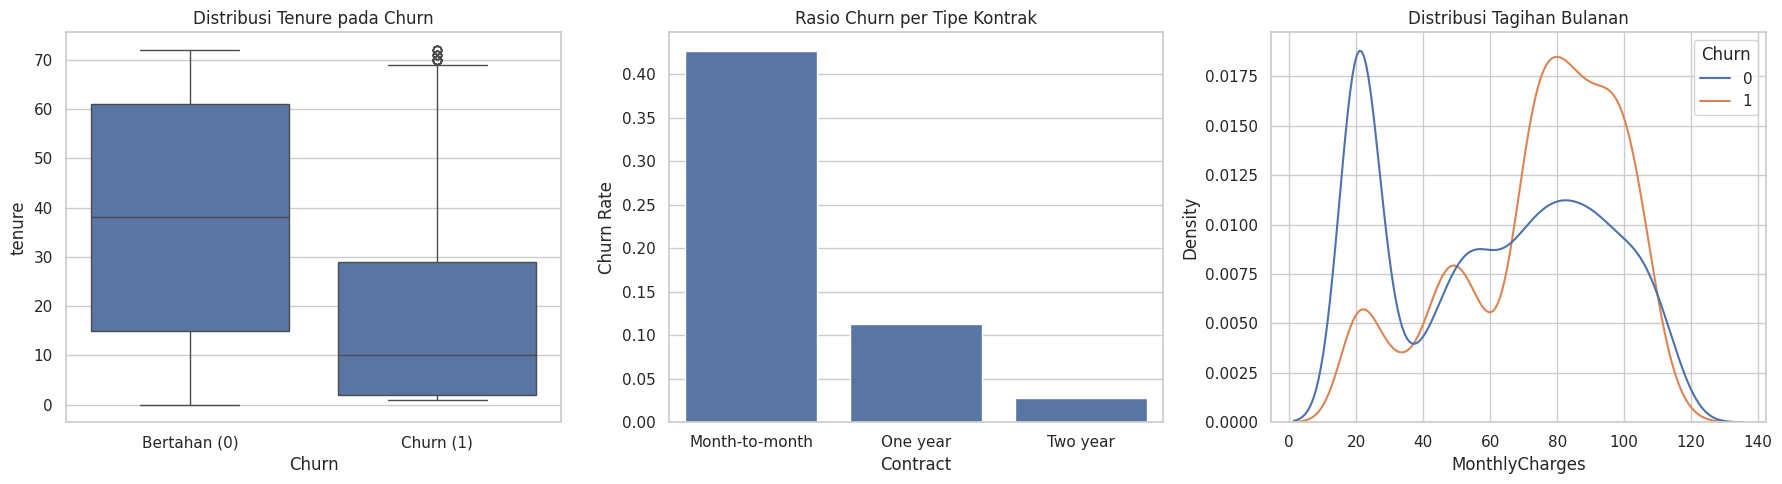

Melatih model dan membandingkan metrik...

--- Hasil Evaluasi Model ---
                    Model  Precision    Recall
0   LogReg (Class Weight)   0.504303  0.783422
1          LogReg (SMOTE)   0.505682  0.713904
2   Random Forest (SMOTE)   0.543124  0.622995
3  XGBoost (Class Weight)   0.534043  0.671123
----------------------------

Mengekstrak Feature Importance dengan SHAP...


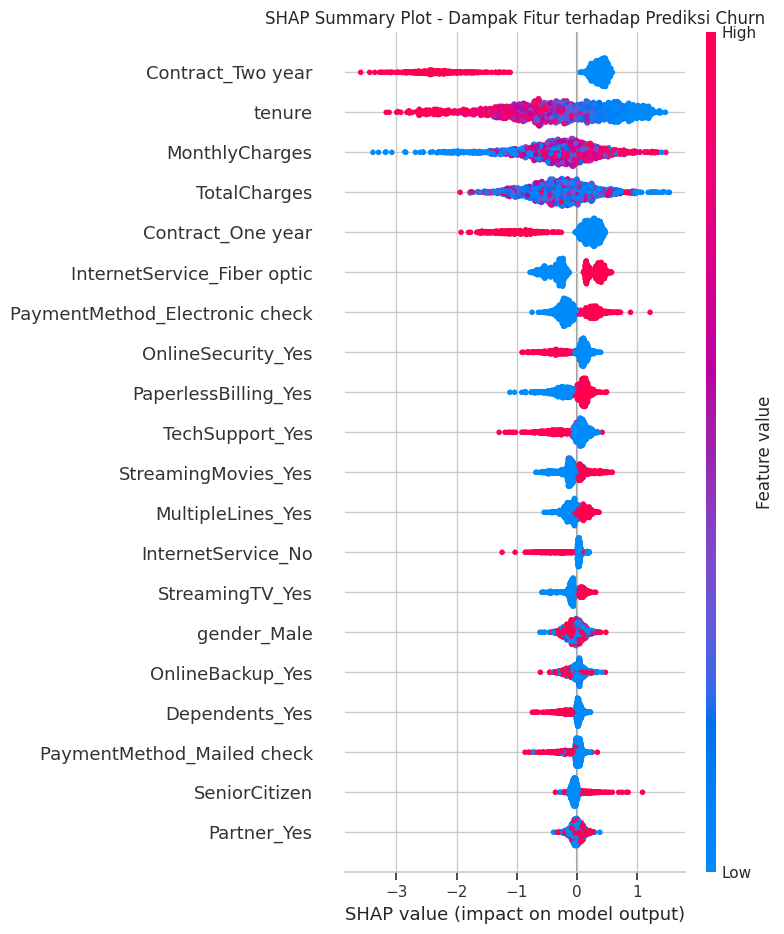

In [16]:
# Gunakan URL raw dari repositori publik sebagai pengganti file lokal
url_dataset = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

print("Memuat dataset...")
df = load_and_clean_data(url_dataset)

# 2. Tampilkan plot EDA (Tutup window plot pertama agar kode berlanjut ke tahap berikutnya)
print("Menampilkan visualisasi EDA...")
perform_directed_eda(df)

# 3. Preprocessing dan pembagian data
X_train, X_test, y_train, y_test = preprocess_and_split(df)

# 4. Evaluasi semua model
print("Melatih model dan membandingkan metrik...")
df_results = evaluate_models(X_train, X_test, y_train, y_test)
print("\n--- Hasil Evaluasi Model ---")
print(df_results)
print("----------------------------\n")

# 5. Melatih ulang model XGBoost terbaik secara spesifik untuk dilempar ke SHAP explainer
print("Mengekstrak Feature Importance dengan SHAP...")
from xgboost import XGBClassifier
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
xgb_best = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
xgb_best.fit(X_train, y_train)

# 6. Tampilkan plot SHAP
explainer, shap_values = interpret_with_shap(xgb_best, X_train, X_test)